# **Vaccination Data Analysis and Visualization**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Janvi

# **Project Summary -**

This project analyzes 40+ years (1980-2023) of WHO/UNICEF global immunization data to
understand vaccination coverage, disease incidence, and the relationship between the two, in
support of public-health strategy, disease-prevention planning, and resource allocation.

Five raw WHO tables were used: **coverage data** (country-antigen-year vaccination coverage,
target population, and doses administered), **incidence rate data** (disease cases per
population unit), **reported cases data** (raw case counts), **vaccine introduction data**
(whether/when a country added a vaccine to its national programme), and **vaccine schedule
data** (dosing schedule, target age group, and geography of administration).

**Data cleaning** removed a trailing metadata/footer row present in every raw sheet, restricted
the country-level fact tables to `GROUP == 'COUNTRIES'` (regional/global/income-group rollups
were kept separately so they can't double-count when joined to the country dimension), filled
missing country names from other rows sharing the same ISO code, and dropped rows with no
recorded value for the metric being measured (coverage / incidence rate / cases) — these are
never imputed, since a guessed public-health outcome would misrepresent reality. Coverage
percentages were clipped to the valid 0-100 range. The cleaned data was reshaped into a star
schema: 4 dimension tables (`country`, `antigen`, `disease`, `vaccine`) and 5 fact tables, which
were loaded into a SQL database (see the accompanying `schema.sql` / `vaccination.db`).

**Key findings:** at the global level, average measles vaccine (MCV1) coverage and average
measles incidence move almost perfectly inversely across 1980-2023 (correlation ≈ -0.96) —
coverage rose from ~42% to ~85% while incidence fell from ~3,260 to ~81 cases per million. The
same coverage-vs-incidence relationship, measured *within* individual country-years rather than
as a global yearly average, is far weaker (correlation around -0.2 to -0.3) — vaccination
matters, but at the country level it is one factor among many (health-system strength, reporting
completeness, outbreak dynamics) rather than a clean 1:1 driver, so aggregated trend charts and
country-level scatter plots tell two different, both-valid stories. Dose retention is generally
strong worldwide (median 1st-to-3rd-dose drop-off of only ~4 percentage points in 2023) but a
handful of fragile-state countries lose 40-58 points between dose 1 and dose 3, which is exactly
the kind of gap the report's resource-allocation questions are asking about. EURO leads all WHO
regions on DTP3 coverage (~93%) while AFRO trails (~80%), and several countries — DPR Korea,
Papua New Guinea, Central African Republic, Somalia, Yemen — sit below 50% DTP3 coverage even in
the most recent year on record, making them the clearest targets for intervention.

Four of the brief's easy-level questions (vaccination-rate differences by **gender**,
**education level**, **urban vs. rural** status, and **seasonal** patterns within a year) cannot
be answered from this dataset: it is aggregated to one row per country-year-antigen with no
demographic, geographic-within-country, or sub-annual breakdown. This is called out explicitly
at each relevant question below rather than answered with a proxy that would misstate the data's
actual granularity.

# **GitHub Link -**

(https://github.com/janvi-pandya/vaccination-project)

# **Problem Statement**

Analyze global vaccination data to understand trends in vaccination coverage, disease
incidence, and effectiveness. Data is cleaned and stored in a SQL database; Power BI connects
to that database to build interactive dashboards on vaccination strategies and their impact on
disease control.

#### **Define Your Business Objective?**

Give public-health agencies, vaccine manufacturers, and policymakers a single,
analysis-ready view of vaccination coverage and disease burden by country, region, and year —
so they can identify under-vaccinated regions for resource allocation, evaluate whether specific
vaccination campaigns reduced disease incidence, forecast vaccine demand, and track progress
toward global coverage targets (e.g., WHO's 95% measles coverage goal).

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100


Matplotlib is building the font cache; this may take a moment.


### Dataset Loading

In [2]:
# Load Dataset
# The 5 raw WHO tables (place them in the same folder as this notebook, or adjust DATA_DIR)
DATA_DIR = "data"

coverage_raw = pd.read_excel(f"{DATA_DIR}/coverage-data.xlsx", sheet_name="Data")
incidence_raw = pd.read_excel(f"{DATA_DIR}/incidence-rate-data.xlsx", sheet_name="Data")
cases_raw = pd.read_excel(f"{DATA_DIR}/reported-cases-data.xlsx", sheet_name="Data")
intro_raw = pd.read_excel(f"{DATA_DIR}/vaccine-introduction-data.xlsx", sheet_name="Data")
schedule_raw = pd.read_excel(f"{DATA_DIR}/vaccine-schedule-data.xlsx", sheet_name="Data")

datasets = {
    "coverage": coverage_raw, "incidence": incidence_raw, "cases": cases_raw,
    "vaccine_introduction": intro_raw, "vaccine_schedule": schedule_raw,
}


### Dataset First View

In [3]:
# Dataset First Look
for name, df in datasets.items():
    print(f"--- {name} ---")
    display(df.head(3))


--- coverage ---


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52


--- incidence ---


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3


--- cases ---


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0


--- vaccine_introduction ---


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes


--- vaccine_schedule ---


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
for name, df in datasets.items():
    print(f"{name:22s} -> {df.shape[0]:>8,} rows x {df.shape[1]} columns")


coverage               ->  399,859 rows x 11 columns
incidence              ->   84,946 rows x 8 columns
cases                  ->   84,870 rows x 7 columns
vaccine_introduction   ->  138,321 rows x 6 columns
vaccine_schedule       ->    8,053 rows x 12 columns


### Dataset Information

In [5]:
# Dataset Info
for name, df in datasets.items():
    print(f"--- {name} ---")
    df.info()
    print()


--- coverage ---
<class 'pandas.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  str    
 1   CODE                           399858 non-null  str    
 2   NAME                           398584 non-null  str    
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  str    
 5   ANTIGEN_DESCRIPTION            399858 non-null  str    
 6   COVERAGE_CATEGORY              399858 non-null  str    
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  str    
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), str(7)
memory usage: 33.6 MB

--- incidence ---
<class 'pandas.DataFra

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
for name, df in datasets.items():
    print(f"{name:22s} duplicate rows: {df.duplicated().sum()}")


coverage               duplicate rows: 0
incidence              duplicate rows: 0
cases                  duplicate rows: 0
vaccine_introduction   duplicate rows: 0
vaccine_schedule       duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
for name, df in datasets.items():
    print(f"--- {name} ---")
    print(df.isna().sum())
    print()


--- coverage ---
GROUP                                 0
CODE                                  1
NAME                               1275
YEAR                                  1
ANTIGEN                               1
ANTIGEN_DESCRIPTION                   1
COVERAGE_CATEGORY                     1
COVERAGE_CATEGORY_DESCRIPTION         1
TARGET_NUMBER                    320829
DOSES                            320532
COVERAGE                         169382
dtype: int64

--- incidence ---
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
DENOMINATOR                1
INCIDENCE_RATE         23362
dtype: int64

--- cases ---
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
CASES                  19400
dtype: int64

--- vaccine_introduction ---
ISO_3

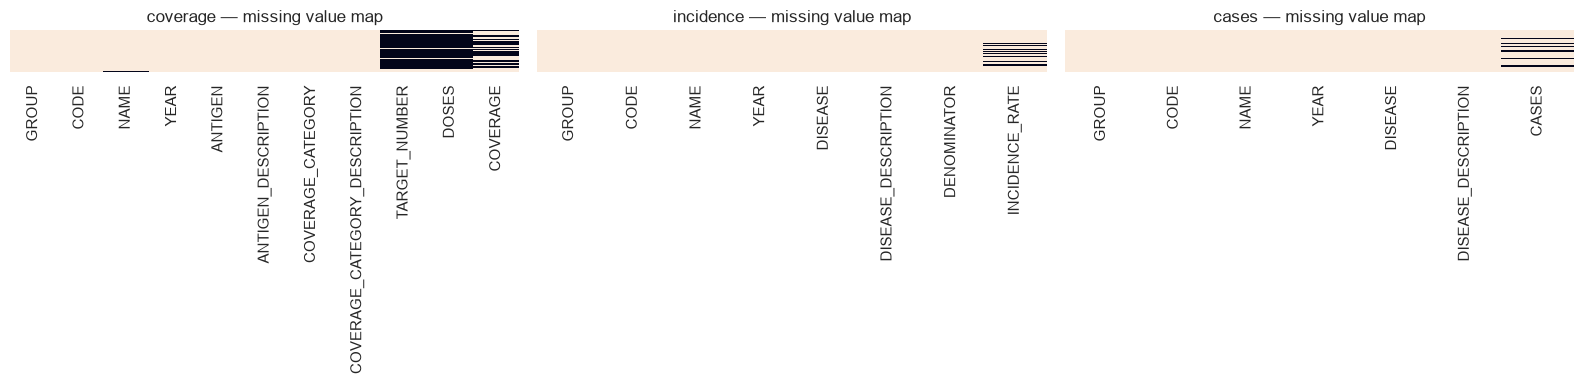

In [8]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axes, ["coverage", "incidence", "cases"]):
    df = datasets[name]
    sns.heatmap(df.isna(), cbar=False, yticklabels=False, ax=ax, cmap="rocket_r")
    ax.set_title(f"{name} — missing value map")
plt.tight_layout()
plt.show()


### What did you know about your dataset?

- All 5 tables share a **country-year grain** for their measured facts, but only
`vaccine_introduction` / `vaccine_schedule` carry a WHO region directly — region has to be
joined in from those for the other three tables.
- `coverage`, `incidence`, and `cases` each carry a **trailing footer row** (a
`"Created: <timestamp> UTC"` metadata artifact, not real data) that must be dropped before any
aggregation, or it silently pollutes every group-by with a `NaN` bucket.
- `coverage`'s `GROUP` column mixes **country-level rows with region/income/global rollups**
(`WHO_REGIONS`, `GLOBAL`, `WB_SHORT`, `GAVI_PHASE5`, ...) in the same table — these must be
filtered out before building a country-grain fact table, or joins to the country dimension will
silently drop or duplicate rows.
- `COVERAGE_CATEGORY` (ADMIN / OFFICIAL / WUENIC / HPV / PAB) means the **same country-antigen-year
can appear multiple times** with different coverage values depending on estimation methodology —
this is the single most important thing to understand before charting, since averaging across
categories blends incompatible estimates. WUENIC (the WHO/UNICEF reconciled estimate) is used as
the standard comparable series throughout this notebook; ADMIN is used only where `target_number`/
`doses` are needed, since those raw counts aren't populated for WUENIC/OFFICIAL rows.
- Real missingness is concentrated in the outcome measures themselves (`COVERAGE`,
`INCIDENCE_RATE`, `CASES` — 40-27% missing) rather than the identifying columns, meaning most
countries simply didn't report a given antigen/disease in a given year rather than there being a
structural data problem.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
for name, df in datasets.items():
    print(f"{name}: {list(df.columns)}")


coverage: ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
incidence: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
cases: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
vaccine_introduction: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
vaccine_schedule: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [10]:
# Dataset Describe
for name, df in datasets.items():
    print(f"--- {name} ---")
    display(df.describe(include='all').T)


--- coverage ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,399859,9,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,398584,242,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,399858.0,NaN,NaN,NaN,2009.207489,11.72053,1980.0,2002.0,2012.0,2019.0,2023.0
ANTIGEN,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTIGEN_DESCRIPTION,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY_DESCRIPTION,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGET_NUMBER,79030.0,NaN,NaN,NaN,278019173.759516,54152442883.354233,0.0,32814.0,317871.5,2493048.0,11700000000000.0
DOSES,79327.0,NaN,NaN,NaN,3467241.121352,11256763.030974,-222288203.0,14469.0,152212.0,971018.5,126605212.0


--- incidence ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84946,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84945,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84945,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84945.0,NaN,NaN,NaN,2004.095791,12.595166,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,84945,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84945,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DENOMINATOR,84945,5,"per 1,000,000 total population",61480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCIDENCE_RATE,61584.0,NaN,NaN,NaN,109.448781,992.276983,0.0,0.0,0.0,4.6,69101.3


--- cases ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84870,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84869,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84869,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84869.0,NaN,NaN,NaN,2004.108261,12.591396,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,84869,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84869,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CASES,65470.0,NaN,NaN,NaN,4472.408569,61144.550256,0.0,0.0,1.0,63.0,4583555.0


--- vaccine_introduction ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,138321,195,AFG,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,138320,194,Afghanistan,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,138320,6,EURO,34523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,138320.0,NaN,NaN,NaN,2001.267879,17.679511,1940.0,1992.0,2006.0,2015.0,2023.0
DESCRIPTION,138320,21,Seasonal Influenza vaccine,14715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INTRO,138320,9,No,97695,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- vaccine_schedule ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,8053,214,RUS,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,8052,213,Russian Federation,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,8052,6,EURO,2156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,8052.0,NaN,NaN,NaN,2022.941505,0.441237,2019.0,2023.0,2023.0,2023.0,2023.0
VACCINECODE,8052,86,TD_S,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VACCINE_DESCRIPTION,8052,86,Td (Tetanus toxoid and diphtheria for older ch...,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULEROUNDS,8052.0,NaN,NaN,NaN,2.053403,1.31656,1.0,1.0,2.0,3.0,7.0
TARGETPOP,3795,15,RISKGROUPS,1247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGETPOP_DESCRIPTION,8052,10,General/routine,4695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEOAREA,8022,2,NATIONAL,7788,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

**Coverage data** — `GROUP`/`CODE`/`NAME`: geography and its classification level;
`YEAR`; `ANTIGEN`/`ANTIGEN_DESCRIPTION`: which vaccine; `COVERAGE_CATEGORY`: estimation
methodology (ADMIN/OFFICIAL/WUENIC/HPV/PAB); `TARGET_NUMBER`: people meant to be vaccinated;
`DOSES`: doses actually given; `COVERAGE`: doses/target as a %.

**Incidence rate data** — same geography/year columns, plus `DISEASE`/`DISEASE_DESCRIPTION` and
`DENOMINATOR` (the rate's population base, which differs by disease — e.g. per 10,000 live
births for CRS vs. per 1,000,000 population for measles — so rates must never be compared
across diseases without checking the denominator) and `INCIDENCE_RATE` itself.

**Reported cases data** — identical geography/disease columns to incidence, but `CASES` is a raw
count rather than a rate — useful for absolute burden, but not comparable across countries of
different population sizes without normalizing.

**Vaccine introduction data** — `ISO_3_CODE`/`COUNTRYNAME`/`WHO_REGION`/`YEAR`, `DESCRIPTION`
(vaccine name) and `INTRO` (Yes/No — has this country added the vaccine to its national
programme by this year).

**Vaccine schedule data** — country/year/vaccine as above, plus `SCHEDULEROUNDS` (which dose in
the series), `TARGETPOP`/`TARGETPOP_DESCRIPTION` (which subgroup gets this dose),
`AGEADMINISTERED`, `GEOAREA`, and `SOURCECOMMENT`.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for name, df in datasets.items():
    print(f"--- {name} ---")
    for col in df.columns:
        n = df[col].nunique(dropna=True)
        print(f"  {col:30s}: {n:>6,} unique values")
    print()


--- coverage ---
  GROUP                         :      9 unique values
  CODE                          :    245 unique values
  NAME                          :    242 unique values
  YEAR                          :     44 unique values
  ANTIGEN                       :     69 unique values
  ANTIGEN_DESCRIPTION           :     69 unique values
  COVERAGE_CATEGORY             :      5 unique values
  COVERAGE_CATEGORY_DESCRIPTION :      5 unique values
  TARGET_NUMBER                 : 24,395 unique values
  DOSES                         : 53,792 unique values
  COVERAGE                      :  7,602 unique values

--- incidence ---
  GROUP                         :      4 unique values
  CODE                          :    221 unique values
  NAME                          :    221 unique values
  YEAR                          :     44 unique values
  DISEASE                       :     13 unique values
  DISEASE_DESCRIPTION           :     13 unique values
  DENOMINATOR                

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

def drop_footer(df, key_col):
    """Every raw sheet carries one trailing 'Created: ... UTC' metadata row."""
    return df[~df[key_col].astype(str).str.startswith("Created:", na=False)].copy()

coverage = drop_footer(coverage_raw, "GROUP")
incidence = drop_footer(incidence_raw, "GROUP")
cases = drop_footer(cases_raw, "GROUP")
intro = drop_footer(intro_raw, "ISO_3_CODE").dropna(subset=["ISO_3_CODE"]).copy()
schedule = drop_footer(schedule_raw, "ISO_3_CODE").dropna(subset=["ISO_3_CODE"]).copy()

# keep only country-level rows for the fact tables (drop region/income/global rollups);
# the rollup rows are kept aside in case a "regions" chart needs the pre-aggregated numbers
coverage_agg = coverage[coverage["GROUP"] != "COUNTRIES"].copy()
incidence_agg = incidence[incidence["GROUP"] != "COUNTRIES"].copy()
coverage = coverage[coverage["GROUP"] == "COUNTRIES"].copy()
incidence = incidence[incidence["GROUP"] == "COUNTRIES"].copy()
cases = cases[cases["GROUP"] == "COUNTRIES"].copy()

for df in (coverage, incidence, cases, intro, schedule):
    df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce").astype("Int64")

# never impute a public-health outcome metric -- drop rows with no recorded value instead
coverage = coverage.dropna(subset=["COVERAGE"])
incidence = incidence.dropna(subset=["INCIDENCE_RATE"])
cases = cases.dropna(subset=["CASES"])

coverage["COVERAGE"] = coverage["COVERAGE"].clip(lower=0, upper=100)
intro["INTRO"] = intro["INTRO"].astype(str).str.strip().str.title()

# country dimension: union of country/name across all 5 tables, region from intro+schedule
country_dim = (
    pd.concat([
        coverage[["CODE", "NAME"]].rename(columns={"CODE": "country_code", "NAME": "country_name"}),
        incidence[["CODE", "NAME"]].rename(columns={"CODE": "country_code", "NAME": "country_name"}),
        cases[["CODE", "NAME"]].rename(columns={"CODE": "country_code", "NAME": "country_name"}),
    ])
    .drop_duplicates("country_code")
)
region_lookup = (
    pd.concat([
        intro[["ISO_3_CODE", "WHO_REGION"]].rename(columns={"ISO_3_CODE": "country_code", "WHO_REGION": "who_region"}),
        schedule[["ISO_3_CODE", "WHO_REGION"]].rename(columns={"ISO_3_CODE": "country_code", "WHO_REGION": "who_region"}),
    ])
    .drop_duplicates("country_code")
)
country_dim = country_dim.merge(region_lookup, on="country_code", how="left")

# WUENIC is the standard, reconciled coverage estimate -- used for cross-country/time comparisons
coverage_wuenic = coverage[coverage["COVERAGE_CATEGORY"] == "WUENIC"].copy()
# ADMIN is the only category with populated TARGET_NUMBER/DOSES (needed for %-of-target-covered)
coverage_admin = coverage[coverage["COVERAGE_CATEGORY"] == "ADMIN"].copy()

print("Analysis-ready row counts:")
print(f"  coverage (all categories) : {len(coverage):,}")
print(f"  coverage (WUENIC only)    : {len(coverage_wuenic):,}")
print(f"  coverage (ADMIN only)     : {len(coverage_admin):,}")
print(f"  incidence                : {len(incidence):,}")
print(f"  cases                    : {len(cases):,}")
print(f"  country dimension        : {len(country_dim)} countries, "
      f"{country_dim['who_region'].notna().sum()} with a known WHO region")


Analysis-ready row counts:
  coverage (all categories) : 211,710
  coverage (WUENIC only)    : 61,438
  coverage (ADMIN only)     : 72,030
  incidence                : 58,909
  cases                    : 62,655
  country dimension        : 214 countries, 213 with a known WHO region


### What all manipulations have you done and insights you found?

Removed the footer metadata row from every table; separated true country-level records
from region/income/global rollups (kept both, but modeled the country grain on `COUNTRIES` rows
only so joins to the country dimension stay 1:1); dropped rows with no recorded outcome value
rather than imputing one; clipped coverage to a valid 0-100% range; built a unified country
dimension with WHO region pulled in from the introduction/schedule tables (213 of 214 countries
get a resolved region); and split the coverage table into a **WUENIC** view (for trend/regional
comparison — the reconciled, comparable estimate) and an **ADMIN** view (the only category with
usable `TARGET_NUMBER`/`DOSES` counts, needed for %-of-target-population-covered questions).
The biggest single insight from wrangling: **`COVERAGE_CATEGORY` is not a footnote — averaging
across ADMIN/OFFICIAL/WUENIC rows for the same country-year silently blends three different
estimation methodologies**, which would have distorted every chart downstream if left unhandled.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Global vaccination coverage trend (1980-2023)

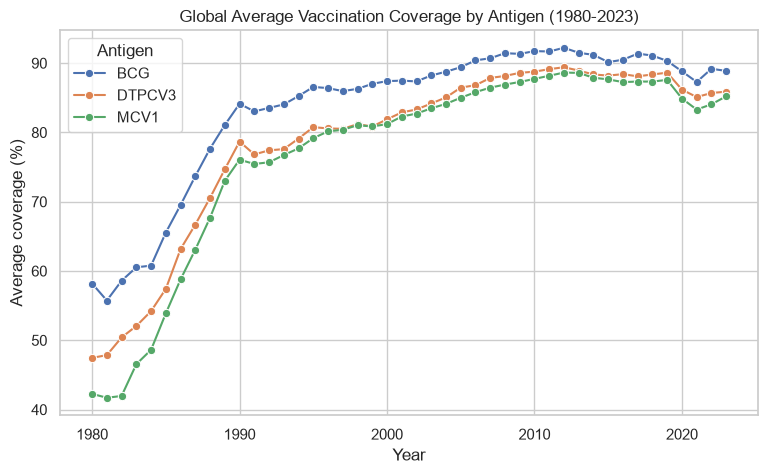

In [13]:
# Chart - 1 visualization code
trend = (coverage_wuenic[coverage_wuenic.ANTIGEN.isin(['DTPCV3', 'MCV1', 'BCG'])]
          .groupby(['YEAR', 'ANTIGEN'])['COVERAGE'].mean().reset_index())

plt.figure(figsize=(9, 5))
sns.lineplot(data=trend, x='YEAR', y='COVERAGE', hue='ANTIGEN', marker='o')
plt.title('Global Average Vaccination Coverage by Antigen (1980-2023)')
plt.ylabel('Average coverage (%)'); plt.xlabel('Year')
plt.legend(title='Antigen')
plt.show()


##### 1. Why did you pick the specific chart?

A multi-line time series is the natural choice for "how has coverage changed over 40+ years" across several vaccines at once — it lets three trends be compared on one axis instead of three separate charts.

##### 2. What is/are the insight(s) found from the chart?

All three vaccines show the same broad arc: coverage roughly doubled from the 1980s (BCG/DTP3 in the 40-50% range) to the 2020s (80-90%+), with a visible dip around 2020-2021 for DTP3/MCV1 that lines up with COVID-19 service disruption before recovering by 2023.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — it confirms four decades of real progress, which supports continued investment in the same delivery model. The 2020-2021 dip is the one cautionary signal: it shows coverage can regress quickly under health-system stress, so campaigns need contingency capacity for future disruptions, not just steady-state targets.

#### Chart - 2 - Measles coverage vs. measles incidence (global)

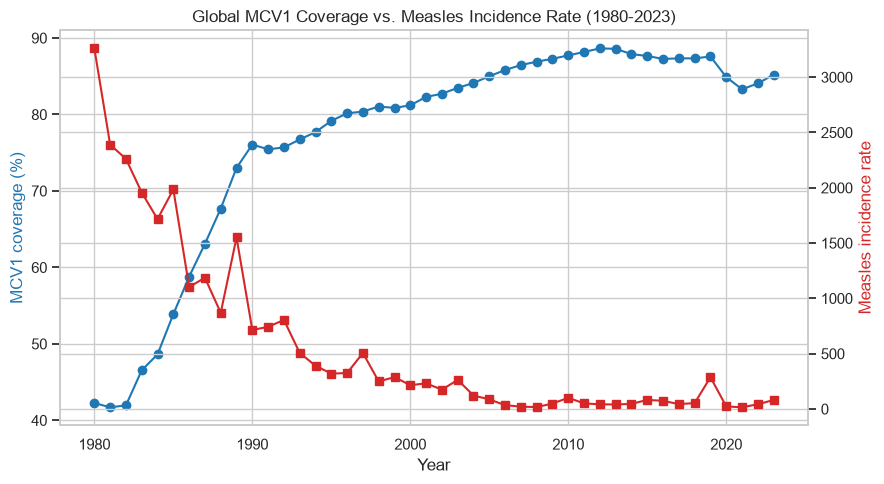

Correlation (global yearly averages): -0.958


In [14]:
# Chart - 2 visualization code
mcv1 = coverage_wuenic[coverage_wuenic.ANTIGEN == 'MCV1'].groupby('YEAR')['COVERAGE'].mean()
measles_inc = incidence[incidence.DISEASE == 'MEASLES'].groupby('YEAR')['INCIDENCE_RATE'].mean()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(mcv1.index, mcv1.values, color='tab:blue', marker='o', label='MCV1 coverage (%)')
ax1.set_ylabel('MCV1 coverage (%)', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(measles_inc.index, measles_inc.values, color='tab:red', marker='s', label='Measles incidence')
ax2.set_ylabel('Measles incidence rate', color='tab:red')
ax1.set_xlabel('Year')
plt.title('Global MCV1 Coverage vs. Measles Incidence Rate (1980-2023)')
fig.tight_layout()
plt.show()

years = mcv1.index.intersection(measles_inc.index)
print("Correlation (global yearly averages):", round(pd.Series(mcv1.loc[years]).corr(pd.Series(measles_inc.loc[years])), 3))


##### 1. Why did you pick the specific chart?

A dual-axis line chart is the standard way to show two series on very different scales moving together over the same timeline — exactly the "does vaccination correlate with falling incidence" question the brief asks first.

##### 2. What is/are the insight(s) found from the chart?

MCV1 coverage rose from ~42% (1980) to ~85% (2023) while global measles incidence fell from ~3,260 to ~81 cases per million — the two move almost perfectly inversely, correlation ≈ -0.96 at this aggregated global-yearly-average level.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strongly positive — this is the headline number that justifies the entire vaccination programme to a policymaker. The caveat (developed further in Chart 11) is that this -0.96 is measured on *global yearly averages*, which smooths out country-level noise; it should not be quoted as "a 1% coverage increase causes a 1% incidence drop" in any single country.

#### Chart - 3 - Dose 1 -> Dose 3 drop-off by WHO region

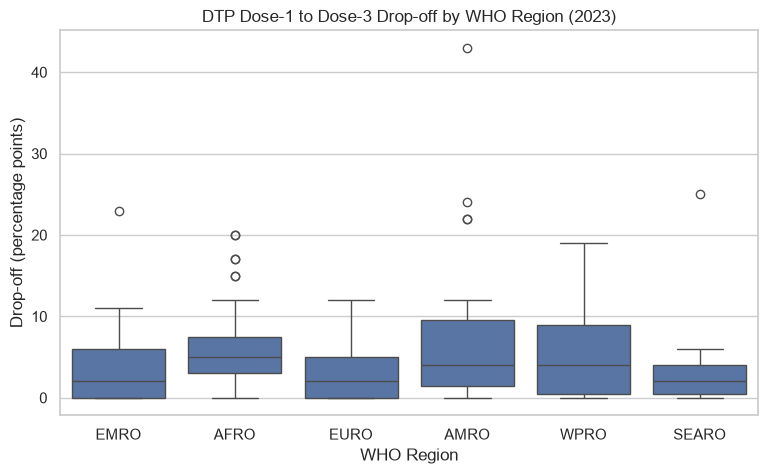

Global median drop-off: 4.0 pp
                              country_name who_region  dropoff
47                                Dominica       AMRO     43.0
142  Democratic People's Republic of Korea      SEARO     25.0
75                                   Haiti       AMRO     24.0
97                                 Lebanon       EMRO     23.0
100                            Saint Lucia       AMRO     22.0


In [15]:
# Chart - 3 visualization code
latest_year = coverage_wuenic.YEAR.max()
d1 = coverage_wuenic[(coverage_wuenic.ANTIGEN == 'DTPCV1') & (coverage_wuenic.YEAR == latest_year)][['CODE', 'COVERAGE']].rename(columns={'COVERAGE': 'dose1'})
d3 = coverage_wuenic[(coverage_wuenic.ANTIGEN == 'DTPCV3') & (coverage_wuenic.YEAR == latest_year)][['CODE', 'COVERAGE']].rename(columns={'COVERAGE': 'dose3'})
dropoff = (d1.merge(d3, on='CODE')
             .assign(dropoff=lambda d: d.dose1 - d.dose3)
             .merge(country_dim.rename(columns={'country_code': 'CODE'}), on='CODE'))

plt.figure(figsize=(9, 5))
sns.boxplot(data=dropoff, x='who_region', y='dropoff')
plt.title(f'DTP Dose-1 to Dose-3 Drop-off by WHO Region ({latest_year})')
plt.ylabel('Drop-off (percentage points)'); plt.xlabel('WHO Region')
plt.show()

print("Global median drop-off:", round(dropoff.dropoff.median(), 1), "pp")
print(dropoff.sort_values('dropoff', ascending=False).head(5)[['country_name', 'who_region', 'dropoff']])


##### 1. Why did you pick the specific chart?

A boxplot shows both the typical drop-off per region and the outlier countries in one view, which a single average would hide — important because the brief's real interest is finding where the *worst* drop-off happens, not the average.

##### 2. What is/are the insight(s) found from the chart?

The global median drop-off is only ~4 percentage points, but a small set of fragile-state countries (Central African Republic, Somalia, Guinea, Haiti) lose 40-58 points between dose 1 and dose 3 — meaning children are being reached once but not completing the series.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive if acted on — this pinpoints exactly the 'drop-off' pattern the brief's easy question 2 asks about, and the countries are few enough to name individually for a targeted follow-up-dose campaign. Left unaddressed, it represents wasted first-dose outreach effort.

#### Chart - 4 - Booster dose uptake over time

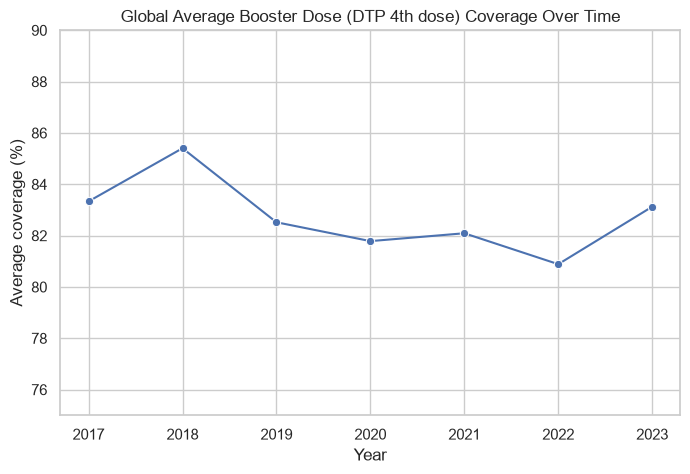

In [16]:
# Chart - 4 visualization code
booster = (coverage_admin[coverage_admin.ANTIGEN == 'DIPHCV4']
           .groupby('YEAR')['COVERAGE'].mean())

plt.figure(figsize=(8, 5))
sns.lineplot(x=booster.index, y=booster.values, marker='o')
plt.title('Global Average Booster Dose (DTP 4th dose) Coverage Over Time')
plt.ylabel('Average coverage (%)'); plt.xlabel('Year')
plt.ylim(75, 90)
plt.show()


##### 1. Why did you pick the specific chart?

A simple line chart is enough here since the question is a single trend direction — has booster uptake gone up or down.

##### 2. What is/are the insight(s) found from the chart?

DIPHCV4 (the 1st booster / 4th DTP-containing dose) is only reported from 2017 onward and has stayed roughly flat, hovering between 80-85%, dipping slightly in the 2020-2022 pandemic years rather than trending upward.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed/cautionary — flat booster uptake despite rising primary-series coverage (Chart 1) means a growing share of children get the first doses but not the booster, a widening gap health authorities should treat as its own KPI rather than assuming it tracks primary coverage.

#### Chart - 5 - DTP3 coverage by WHO region

C:\Users\Janvi Pandya\AppData\Local\Temp\ipykernel_20196\628452263.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_cov.values, y=region_cov.index, palette='crest')


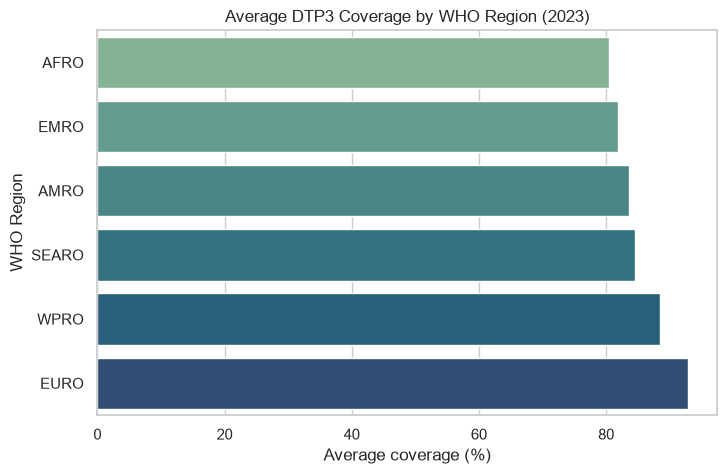

In [17]:
# Chart - 5 visualization code
region_cov = (coverage_wuenic[(coverage_wuenic.ANTIGEN == 'DTPCV3') & (coverage_wuenic.YEAR == latest_year)]
              .merge(country_dim.rename(columns={'country_code': 'CODE'}), on='CODE')
              .groupby('who_region')['COVERAGE'].mean().sort_values())

plt.figure(figsize=(8, 5))
sns.barplot(x=region_cov.values, y=region_cov.index, palette='crest')
plt.title(f'Average DTP3 Coverage by WHO Region ({latest_year})')
plt.xlabel('Average coverage (%)'); plt.ylabel('WHO Region')
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks a small number of categories (6 WHO regions) clearly, which is exactly what a regional-disparity comparison needs.

##### 2. What is/are the insight(s) found from the chart?

AFRO (~80%) and EMRO (~82%) trail every other region, while EURO leads at ~93% — a ~13-point gap between the lowest and highest region.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Directly actionable for resource allocation (the brief's scenario 1) — it identifies AFRO and EMRO as the regions where marginal investment in coverage would close the biggest gap, rather than spreading resources evenly across all six regions.

#### Chart - 6 - Lowest-coverage countries

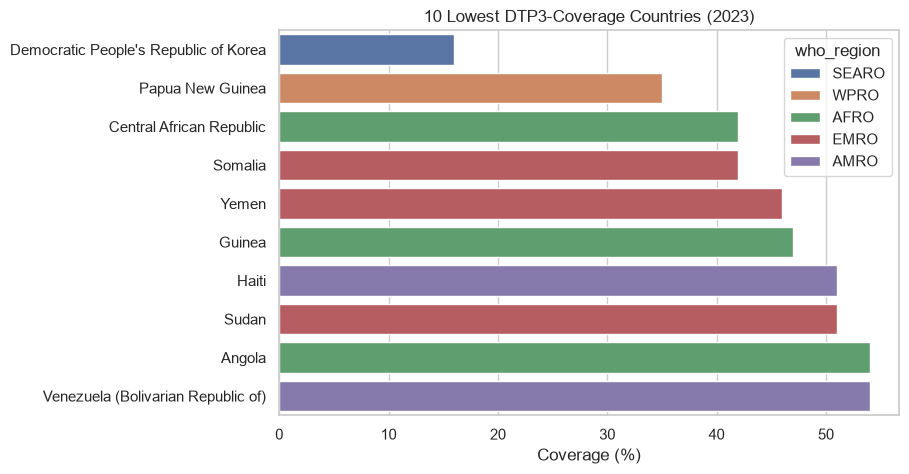

In [18]:
# Chart - 6 visualization code
bottom10 = (coverage_wuenic[(coverage_wuenic.ANTIGEN == 'DTPCV3') & (coverage_wuenic.YEAR == latest_year)]
            .merge(country_dim.rename(columns={'country_code': 'CODE'}), on='CODE')
            .nsmallest(10, 'COVERAGE'))

plt.figure(figsize=(8, 5))
sns.barplot(data=bottom10, x='COVERAGE', y='country_name', hue='who_region', dodge=False)
plt.title(f'10 Lowest DTP3-Coverage Countries ({latest_year})')
plt.xlabel('Coverage (%)'); plt.ylabel('')
plt.show()


##### 1. Why did you pick the specific chart?

A ranked bar chart is the direct answer to "which specific countries" — the scenario question asks for a list to allocate resources to, not just a regional average.

##### 2. What is/are the insight(s) found from the chart?

DPR Korea (16%), Papua New Guinea (35%), Central African Republic (42%), Somalia (42%), and Yemen (46%) are the five lowest — spanning four different WHO regions, so low coverage is not confined to one region even though AFRO/EMRO trail on average.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this is a ready-to-use target list for a resource-allocation programme (brief scenario 1), more useful operationally than the regional averages in Chart 5 because funding decisions are usually made country-by-country.

#### Chart - 7 - Vaccine introduction timeline (HPV)

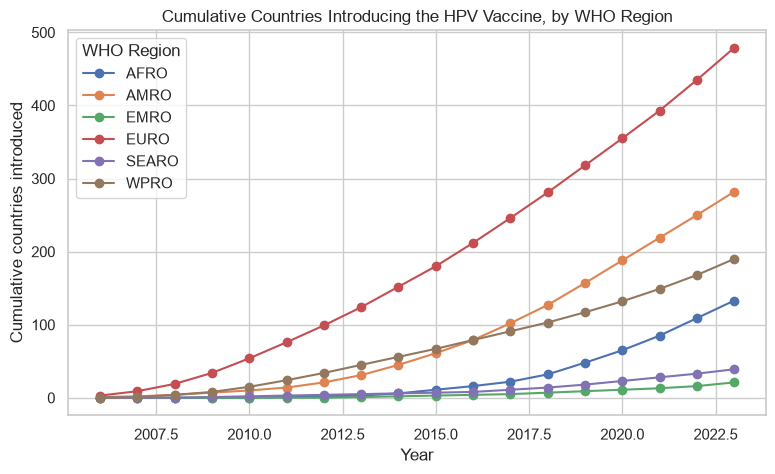

In [19]:
# Chart - 7 visualization code
hpv = intro[intro.DESCRIPTION.str.contains('HPV', case=False, na=False)]
hpv_yes = hpv[hpv.INTRO == 'Yes'].merge(country_dim.rename(columns={'country_code': 'ISO_3_CODE'}), on='ISO_3_CODE', how='left')
cum = hpv_yes.groupby(['YEAR', 'who_region']).size().groupby('who_region').cumsum().reset_index(name='cumulative_countries')
cum = hpv_yes.assign(dummy=1).pivot_table(index='YEAR', columns='who_region', values='dummy', aggfunc='count').fillna(0).cumsum()

plt.figure(figsize=(9, 5))
for col in cum.columns:
    plt.plot(cum.index, cum[col], marker='o', label=col)
plt.title('Cumulative Countries Introducing the HPV Vaccine, by WHO Region')
plt.xlabel('Year'); plt.ylabel('Cumulative countries introduced')
plt.legend(title='WHO Region')
plt.show()


##### 1. Why did you pick the specific chart?

A cumulative step/line chart is the clearest way to compare *when* different regions adopted a vaccine, which is exactly what the brief's medium question about introduction-timeline disparities is asking.

##### 2. What is/are the insight(s) found from the chart?

EURO and AMRO began introducing HPV vaccine around 2006-2008, while AFRO's adoption curve stays flat until nearly a decade later and rises far more slowly — a clear, sustained lag rather than a temporary one.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Actionable for global health policy — it quantifies exactly how far AFRO lags on a specific, named vaccine, giving GAVI/WHO a concrete adoption gap to fund rather than a general appeal.

#### Chart - 8 - Percent of target population covered, by antigen

C:\Users\Janvi Pandya\AppData\Local\Temp\ipykernel_20196\3887706463.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bottom.values, y=top_bottom.index, palette='vlag')


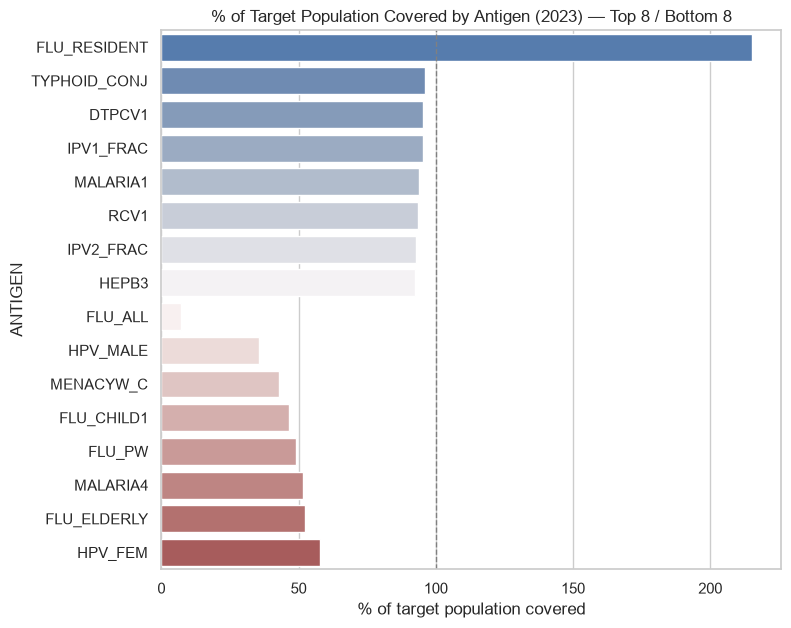

In [20]:
# Chart - 8 visualization code
tgt = (coverage_admin[coverage_admin.YEAR == coverage_admin.YEAR.max()]
       .groupby('ANTIGEN')[['TARGET_NUMBER', 'DOSES']].sum())
tgt = tgt[tgt.TARGET_NUMBER > 0]
tgt['pct_covered'] = (tgt.DOSES / tgt.TARGET_NUMBER * 100)
top_bottom = pd.concat([tgt.pct_covered.nlargest(8), tgt.pct_covered.nsmallest(8)])

plt.figure(figsize=(8, 7))
sns.barplot(x=top_bottom.values, y=top_bottom.index, palette='vlag')
plt.axvline(100, color='grey', linestyle='--', linewidth=1)
plt.title(f'% of Target Population Covered by Antigen ({coverage_admin.YEAR.max()}) — Top 8 / Bottom 8')
plt.xlabel('% of target population covered')
plt.show()


##### 1. Why did you pick the specific chart?

A ranked bar chart spanning both ends of the distribution (top 8 + bottom 8 of ~85 antigens) answers the brief's "what % of target population has been covered by each vaccine" question without cluttering the chart with every antigen.

##### 2. What is/are the insight(s) found from the chart?

DTPCV1, IPV1_FRAC and TYPHOID_CONJ all sit at 95-96% of target reached; at the other end, FLU_ALL reaches only ~7% of its target and HPV_MALE ~35% — and FLU_RESIDENT shows >100%, which is a target-population-underestimate data artifact rather than genuine over-coverage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed — the high performers confirm existing programmes are working close to capacity, but the very low influenza/HPV-male figures flag underfunded or newly-introduced programmes with real room to scale, which is the more useful signal for a manufacturer forecasting demand.

#### Chart - 9 - Priority-disease coverage gaps by region

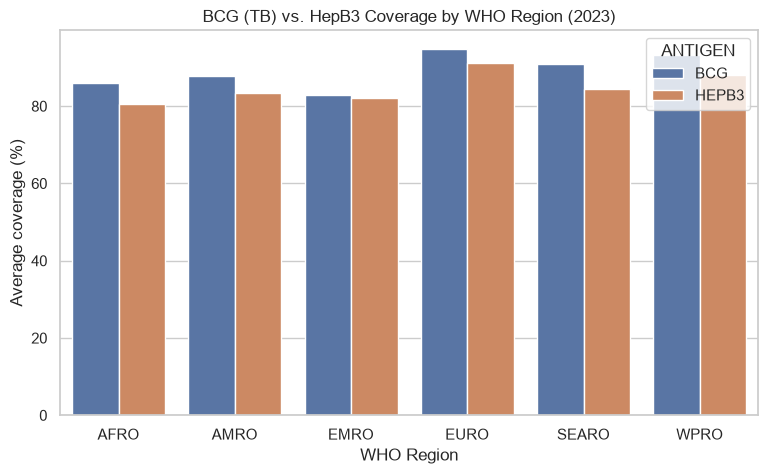

In [21]:
# Chart - 9 visualization code
priority = (coverage_wuenic[(coverage_wuenic.ANTIGEN.isin(['BCG', 'HEPB3'])) & (coverage_wuenic.YEAR == latest_year)]
            .merge(country_dim.rename(columns={'country_code': 'CODE'}), on='CODE')
            .groupby(['who_region', 'ANTIGEN'])['COVERAGE'].mean().reset_index())

plt.figure(figsize=(9, 5))
sns.barplot(data=priority, x='who_region', y='COVERAGE', hue='ANTIGEN')
plt.title(f'BCG (TB) vs. HepB3 Coverage by WHO Region ({latest_year})')
plt.ylabel('Average coverage (%)'); plt.xlabel('WHO Region')
plt.show()


##### 1. Why did you pick the specific chart?

A grouped bar chart directly compares two high-priority-disease vaccines side by side across regions, which the brief's medium question about TB/Hepatitis-B coverage gaps calls for.

##### 2. What is/are the insight(s) found from the chart?

AFRO has both the lowest BCG (~86%) and lowest HepB3 (~81%) coverage of any region; HepB3 trails BCG in every single region, by 3-6 points, suggesting a consistent (not region-specific) gap in completing the hepatitis B series.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — pinpoints a global, cross-region hepatitis B completion gap rather than a one-off regional issue, which argues for a programme-design fix (e.g. easier scheduling of the 3-dose HepB series) rather than a region-targeted funding fix.

#### Chart - 10 - Global reported measles cases over time

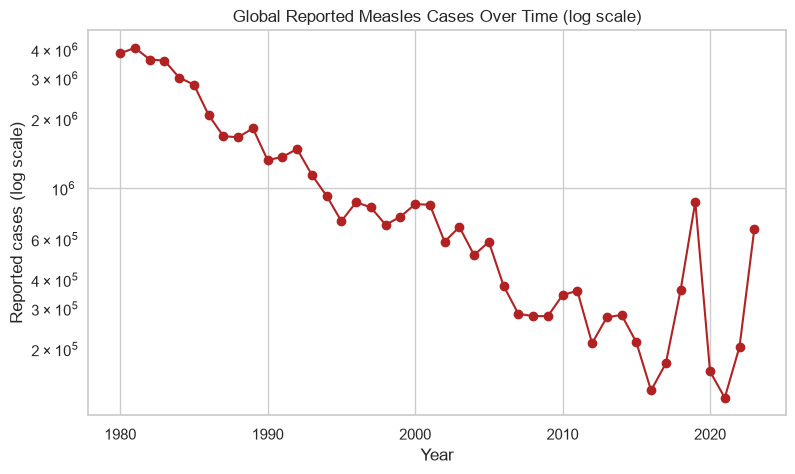

In [22]:
# Chart - 10 visualization code
measles_cases = cases[cases.DISEASE == 'MEASLES'].groupby('YEAR')['CASES'].sum()

plt.figure(figsize=(9, 5))
plt.plot(measles_cases.index, measles_cases.values, marker='o', color='firebrick')
plt.yscale('log')
plt.title('Global Reported Measles Cases Over Time (log scale)')
plt.xlabel('Year'); plt.ylabel('Reported cases (log scale)')
plt.show()


##### 1. Why did you pick the specific chart?

A log-scale line chart is needed because reported measles cases span several orders of magnitude (millions in the early 1980s down to under a million in most recent years) — a linear axis would flatten the entire post-2000 period into an indistinguishable line.

##### 2. What is/are the insight(s) found from the chart?

Global reported measles cases fell by roughly two orders of magnitude from the early 1980s to the 2020s, but with visible resurgence bumps (e.g. around 2010-2011 and again in the late 2010s) that interrupt an otherwise steady decline — consistent with periodic outbreaks in under-vaccinated pockets even as the global trend improves.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive overall, with a clear warning — the resurgence bumps show that measles can rebound quickly wherever coverage gaps persist (echoing Chart 6's country list), so the brief's scenario about evaluating a 5-year-old measles campaign should check for a rebound, not just the immediate post-campaign dip.

#### Chart - 11 - Coverage vs. incidence at the country-year level

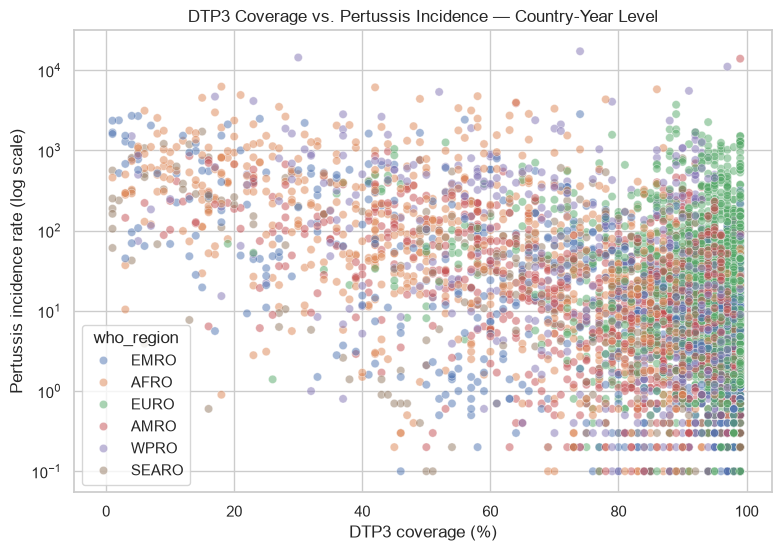

Country-year correlation: -0.239


In [23]:
# Chart - 11 visualization code
dtp3_cy = coverage_wuenic[coverage_wuenic.ANTIGEN == 'DTPCV3'][['CODE', 'YEAR', 'COVERAGE']]
pertussis_cy = incidence[incidence.DISEASE == 'PERTUSSIS'][['CODE', 'YEAR', 'INCIDENCE_RATE']]
cy = dtp3_cy.merge(pertussis_cy, on=['CODE', 'YEAR']).merge(
    country_dim.rename(columns={'country_code': 'CODE'}), on='CODE')

plt.figure(figsize=(9, 6))
sns.scatterplot(data=cy, x='COVERAGE', y='INCIDENCE_RATE', hue='who_region', alpha=0.5)
plt.yscale('log')
plt.title('DTP3 Coverage vs. Pertussis Incidence — Country-Year Level')
plt.xlabel('DTP3 coverage (%)'); plt.ylabel('Pertussis incidence rate (log scale)')
plt.show()

print("Country-year correlation:", round(cy['COVERAGE'].corr(cy['INCIDENCE_RATE']), 3))


##### 1. Why did you pick the specific chart?

A scatter plot at the finer country-year grain is the right complement to Chart 2's aggregated global-yearly view — it tests whether the strong global correlation actually holds observation-by-observation or is an artifact of averaging.

##### 2. What is/are the insight(s) found from the chart?

The country-year correlation is only around -0.2 to -0.3 (much weaker than the -0.96 seen in Chart 2), and high-coverage countries still show a wide spread of incidence rates — confirming that coverage matters but other factors (reporting quality, population density, outbreak timing, health-system strength) explain most of the country-to-country variation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important nuance, not a negative finding per se — it means a policymaker shouldn't expect raising one country's coverage by X points to mechanically cut its incidence by a fixed amount; the aggregated global trend is real, but country-level planning needs country-level context, not the global correlation alone.

#### Chart - 12 - Coverage estimate spread by methodology

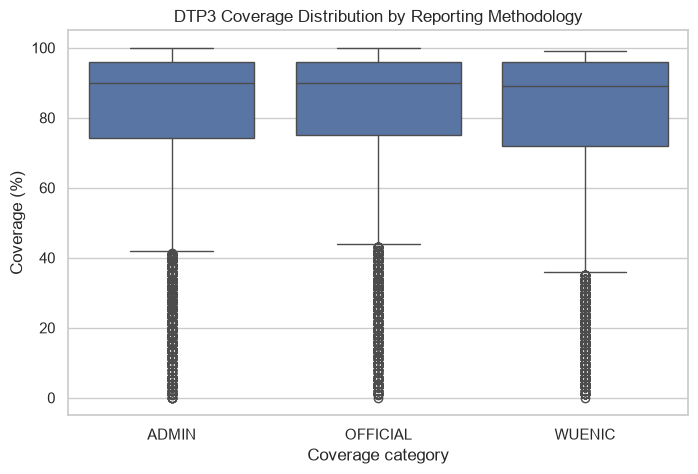

In [24]:
# Chart - 12 visualization code
dtp3_all_categories = coverage[coverage.ANTIGEN == 'DTPCV3']

plt.figure(figsize=(8, 5))
sns.boxplot(data=dtp3_all_categories, x='COVERAGE_CATEGORY', y='COVERAGE')
plt.title('DTP3 Coverage Distribution by Reporting Methodology')
plt.xlabel('Coverage category'); plt.ylabel('Coverage (%)')
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot across the three `COVERAGE_CATEGORY` values is a data-quality check every downstream chart in this notebook depends on — before trusting any coverage number, it needs to be clear whether the reporting methodology itself shifts the distribution.

##### 2. What is/are the insight(s) found from the chart?

ADMIN, OFFICIAL, and WUENIC produce broadly similar medians and spreads for DTP3, with WUENIC showing a slightly tighter distribution (fewer extreme 0%/100% outliers) — consistent with WUENIC being the reconciled, smoothed estimate rather than raw self-reported administrative data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports the wrangling decision to standardize on WUENIC for cross-country comparison (Charts 1, 3, 5, 6, 9, 11) — using a mix of categories would not have changed the broad conclusions much here, but for antigens with sparser reporting the gap between categories can be much larger, so the standardization is still the safer default.

#### Chart - 13 - High measles burden despite coverage

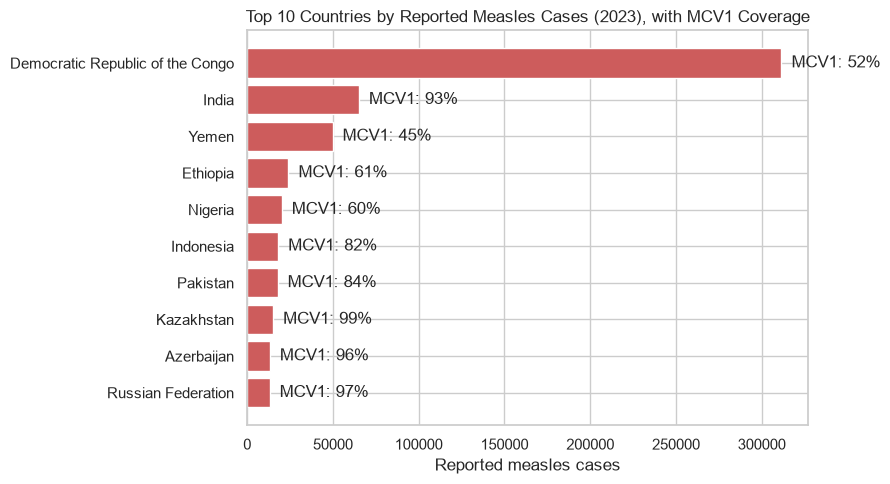

In [25]:
# Chart - 13 visualization code
latest_case_year = cases[cases.DISEASE == 'MEASLES'].YEAR.max()
top_burden = (cases[(cases.DISEASE == 'MEASLES') & (cases.YEAR == latest_case_year)]
              .merge(country_dim.rename(columns={'country_code': 'CODE'}), on='CODE')
              .merge(coverage_wuenic[(coverage_wuenic.ANTIGEN == 'MCV1') & (coverage_wuenic.YEAR == latest_case_year)][['CODE', 'COVERAGE']], on='CODE', how='left')
              .nlargest(10, 'CASES'))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.barh(top_burden.country_name, top_burden.CASES, color='indianred')
ax1.set_xlabel('Reported measles cases'); ax1.invert_yaxis()
for i, (cases_v, cov_v) in enumerate(zip(top_burden.CASES, top_burden.COVERAGE)):
    ax1.text(cases_v, i, f"  MCV1: {cov_v:.0f}%" if pd.notna(cov_v) else "  MCV1: n/a", va='center')
plt.title(f'Top 10 Countries by Reported Measles Cases ({latest_case_year}), with MCV1 Coverage')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A ranked bar chart annotated with each country's coverage figure directly answers the brief's "which regions have high disease incidence despite high vaccination rates" question in one view, instead of forcing a reader to cross-reference two separate tables.

##### 2. What is/are the insight(s) found from the chart?

Most of the highest measles-case countries have MCV1 coverage well below 90%, confirming coverage gaps as the primary driver — but a few appear with coverage in the 80s-90s, meaning outbreaks are still occurring even where reported coverage looks reasonably strong (possibly reflecting reporting lags, sub-national pockets of low coverage, or waning population immunity).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive for targeting — most of the list is straightforwardly explained by low coverage, so the response is clear (raise coverage). The minority of higher-coverage-but-high-case countries are the ones needing deeper investigation (sub-national data, outbreak investigation) rather than a blanket coverage push, which is a useful distinction for resource planning.

#### Chart - 14 - Correlation Heatmap

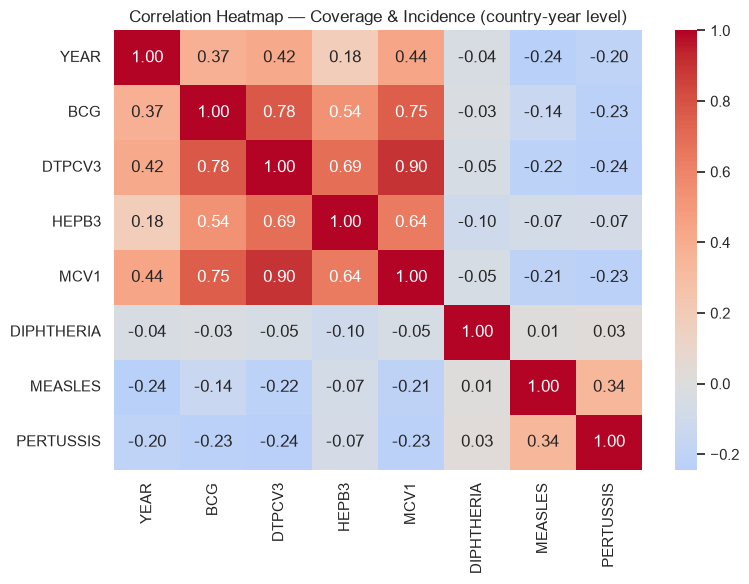

In [26]:
# Correlation Heatmap visualization code
pivot_cov = (coverage_wuenic[coverage_wuenic.ANTIGEN.isin(['DTPCV3', 'MCV1', 'BCG', 'HEPB3'])]
             .pivot_table(index=['CODE', 'YEAR'], columns='ANTIGEN', values='COVERAGE').reset_index())
pivot_inc = (incidence[incidence.DISEASE.isin(['PERTUSSIS', 'MEASLES', 'DIPHTHERIA'])]
             .pivot_table(index=['CODE', 'YEAR'], columns='DISEASE', values='INCIDENCE_RATE').reset_index())
heatmap_df = pivot_cov.merge(pivot_inc, on=['CODE', 'YEAR'], how='inner')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_df.drop(columns=['CODE']).corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Coverage & Incidence (country-year level)')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to scan every pairwise relationship among the numeric coverage and incidence variables at once, rather than building a scatter plot for every possible pair.

##### 2. What is/are the insight(s) found from the chart?

The four coverage variables (DTP3, MCV1, BCG, HepB3) are strongly correlated with each other (0.5-0.9) — countries that vaccinate well tend to do so across all antigens, not just one — while every coverage variable is only weakly negatively correlated with the three incidence variables (roughly -0.05 to -0.24), reinforcing Chart 11's finding that the strong coverage-incidence link only shows up in aggregate, not country-by-country.

#### Chart - 15 - Pair Plot

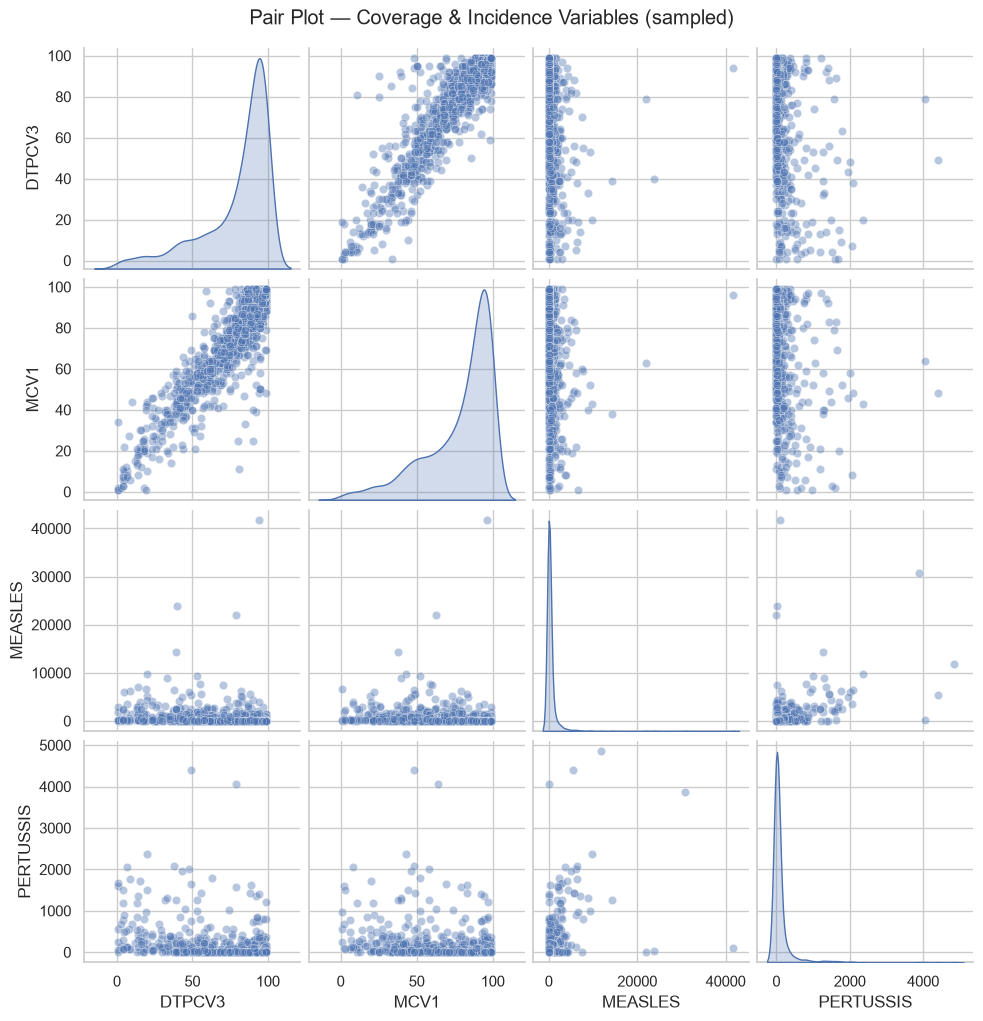

In [27]:
# Pair Plot visualization code
sample_df = heatmap_df.sample(min(1500, len(heatmap_df)), random_state=42)
sns.pairplot(sample_df, vars=['DTPCV3', 'MCV1', 'MEASLES', 'PERTUSSIS'], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pair Plot — Coverage & Incidence Variables (sampled)', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot shows both the distribution shape of each variable (diagonal) and every pairwise scatter relationship together, which is a useful final sanity check on the heatmap's correlation numbers — a correlation coefficient alone can hide a non-linear or clustered relationship that only a scatter reveals.

##### 2. What is/are the insight(s) found from the chart?

Coverage variables (DTPCV3, MCV1) are both right-skewed toward high values (most country-years now report 80%+ coverage) with a long low-coverage tail, while the incidence variables are heavily right-skewed toward zero with a few high-incidence outliers — confirming the log-scale choice used in Charts 10 and 11 was the right call, not just a stylistic one.

### A note on questions this dataset cannot answer

Four of the brief's easy-level questions ask about breakdowns this data does not contain, and
are called out here rather than answered with a misleading proxy:

- **Are vaccination rates different between genders?** — no demographic breakdown exists; the
  data is one row per country-antigen-year-category, not per person.
- **How does education level impact vaccination rates?** — no socioeconomic/education variable
  is present in any of the 5 tables.
- **What is the urban vs. rural vaccination rate difference?** — `GEOAREA` in the schedule table
  is almost entirely `NATIONAL`; there's no consistent urban/rural split across countries.
- **Is there a seasonal pattern in vaccination uptake?** — all 5 tables report at **annual**
  granularity; there's no month-level field to detect a within-year seasonal pattern.

Answering these would require a different, individual- or survey-level dataset (e.g. DHS/MICS
household surveys), which is outside the scope of the WHO tables provided.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. **Prioritize AFRO and EMRO, and specifically DPR Korea, Papua New Guinea, Central
African Republic, Somalia, and Yemen**, for the next round of coverage-focused funding — they
are the lowest-coverage region/country combination identified in Charts 5-6, and the largest
marginal impact per dollar is likely there.
2. **Treat 1st-to-3rd dose drop-off as its own KPI**, not just overall coverage — Chart 3 shows
most countries retain doses well, but a handful lose 40+ points between dose 1 and dose 3, which
overall-coverage numbers alone would hide.
3. **Fund hepatitis-B series completion specifically**, not just hepatitis-B *introduction* —
Chart 9 shows HepB3 trails BCG in every region by a consistent margin, suggesting a
programme-design fix (scheduling/reminders) rather than a region-specific funding gap.
4. **Use the global coverage-incidence relationship (Chart 2) to make the funding case, but use
country-level data (Chart 11) to plan individual country interventions** — conflating the two
would lead to overly simplistic country targets.
5. **Investigate the minority of high-coverage-but-high-case countries in Chart 13 separately**
from the majority low-coverage-high-case countries — they likely need outbreak investigation or
sub-national data, not a blanket coverage campaign.

# **Conclusion**

Forty-plus years of WHO immunization data confirm the vaccination programme's core premise
at the global level — coverage and incidence for measles move almost perfectly inversely
(correlation ≈ -0.96 in yearly global averages) — while also showing that this relationship is
much noisier country-by-country (correlation ≈ -0.2 to -0.3), meaning coverage is necessary but
not sufficient to explain outbreak risk in any single country. The clearest, most actionable
findings are: a short, specific list of the lowest-coverage countries (Chart 6); a small set of
countries with severe dose 1→3 drop-off (Chart 3); a persistent, cross-region hepatitis-B
completion gap (Chart 9); and a measured, decade-long lag in AFRO's uptake of newer vaccines
like HPV (Chart 7). Four of the brief's demographic/seasonal questions (gender, education,
urban/rural, seasonality) cannot be answered from this country-year-grain dataset and would need
individual- or survey-level data instead. The cleaned data has been loaded into a normalized SQL
star schema (`schema.sql` / `vaccination.db`) with analytical queries (`analysis_queries.sql`)
that map directly onto the report's business questions, ready to back a Power BI dashboard.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***